# Entendimiento de las bases 1 por 1



## Curvas de producción

In [42]:
from pathlib import Path
import warnings
import pandas as pd
from openpyxl.worksheet.print_settings import PrintTitles

pd.set_option('display.max_columns', None)

# El libro contiene metadatos de impresión '#N/A' creados por Excel.
# openpyxl 3.1.x no los acepta, aunque los datos de las hojas sí son válidos.
_print_titles_original = PrintTitles.from_string.__func__

def _print_titles_tolerante(cls, value):
    if value in {"#N/A", "#REF!"}:
        return cls()
    return _print_titles_original(cls, value)

PrintTitles.from_string = classmethod(_print_titles_tolerante)
warnings.filterwarnings(
    "ignore",
    message="Print area cannot be set to Defined name.*",
)

# Funciona si Jupyter arrancó en la raíz del proyecto o en esta carpeta.
nombre_archivo = "Estadisticas Miniclavel 2026.xlsx"
candidatos = [
    Path.cwd() / nombre_archivo,
    Path.cwd() / "Primer entendimiento con los muchachos" / nombre_archivo,
]
ruta_archivo = next((p for p in candidatos if p.exists()), None)
if ruta_archivo is None:
    raise FileNotFoundError(f"No encontré {nombre_archivo}. Busqué en: {candidatos}")

excel = pd.ExcelFile(ruta_archivo, engine="openpyxl")
print(f"Archivo: {ruta_archivo}")
print(f"Hojas disponibles ({len(excel.sheet_names)}):")
for i, nombre in enumerate(excel.sheet_names):
    print(f"{i:>2}: {nombre}")

Archivo: c:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Primer entendimiento con los muchachos\Estadisticas Miniclavel 2026.xlsx
Hojas disponibles (28):
 0: semana
 1: Productividad flor x planta_mod
 2: Variedades
 3: curvas historicas
 4: tipo de despunte
 5: Ensayo sustratos 2020-2021
 6: Detalle2
 7: analisis tipo de invernader (2)
 8: analisis tipos de invernadero
 9: B31 sustratos
10: Manejos poda
11: ensayo densidades
12: curva ppto vs real
13: Bloque 4 vs otros
14: Bloque 4 vs Bloque 3
15: Bloques
16: Bloque 4 historico
17: analisis tipo de invernadero
18: Ensayo de densidades 2025-2026
19: Base de datos
20: Camas Piloto
21: proveedores esqueje
22: Ensayo MO
23: filtro tipo invernadero
24: Laboratorio de Sustrato
25: detalle
26: productividad modelo de siembra
27: Productividad


In [43]:
#importación de base de datos

df_curvas = pd.read_excel(ruta_archivo, sheet_name="Base de datos", engine="openpyxl")

print(df_curvas.head())

print("="*100)

print("Columnas de la base de datos:")
print(df_curvas.columns.tolist())   

    CAMA PILOTO  BLOQUE CAMA  SEM Corte  Año Corte  Semana Corte  \
0    PIGEON-1-6     1.0    6        1.0     2014.0      201401.0   
1    PIGEON-1-8     1.0    8        1.0     2014.0      201401.0   
2  BAGATEL-1-13     1.0   13        1.0     2014.0      201401.0   
3  BAGATEL-1-39     1.0   39        1.0     2014.0      201401.0   
4  BAGATEL-1-65     1.0   65        1.0     2014.0      201401.0   

   CORTE SEMANAL   Color Variedad  # Sem Corte  Edad  flores x planta  \
0           23.0  Cereza   PIGEON        209.0  27.0         0.022908   
1          138.0  Cereza   PIGEON        209.0  27.0         0.137450   
2          117.0  Blanco  BAGATEL        209.0  86.0         0.200342   
3          115.0  Blanco  BAGATEL        209.0  79.0         0.112305   
4          155.0  Blanco  BAGATEL        209.0  68.0         0.151961   

      Fecha de Siembra  Semana de Siembra  Año de Siembra Sustrato     CASA  \
0  2013-07-04 00:00:00               27.0          2013.0     S90%   Brei

In [44]:
df_camas = pd.read_excel(
    ruta_archivo,
    sheet_name="Camas Piloto",
    header=1,
    engine="openpyxl"
)

df_camas.columns = df_camas.columns.astype(str).str.strip()

print(df_camas.head())

print("=" * 100)

print("Columnas de la base de datos:")
print(df_camas.columns.tolist())

        Referencia         Color    Variedad No. Bloque No. Cama  \
0   Dracula-15-185          Rojo     Dracula         15      185   
1    Lorenzo-12-19        Cereza     Lorenzo         12       19   
2    Roxanne-1-318        Rosado     Roxanne          1      318   
3    Malibu-18-197          Lila      Malibu         18      197   
4  Number One-4-56  Bicolor Rojo  Number One          4       56   

  Fecha de Siembra  No. Plantas  Sem Siembra  Año Siembra  Sem Siembra.1  \
0              NaN          NaN          1.0       1900.0       190001.0   
1              NaN          NaN          1.0       1900.0       190001.0   
2              NaN          NaN          1.0       1900.0       190001.0   
3              NaN          NaN          1.0       1900.0       190001.0   
4              NaN          NaN          1.0       1900.0       190001.0   

   #Sem Sustrato  PROVEEDOR ESQUEJE  Casa  ancho de cama  \
0   NaN      NaN                NaN   NaN            NaN   
1   NaN     S9

### Limpieza y EDA

In [45]:
print(df_curvas.head())
print("=" * 100)
print(df_curvas.tail())

    CAMA PILOTO  BLOQUE CAMA  SEM Corte  Año Corte  Semana Corte  \
0    PIGEON-1-6     1.0    6        1.0     2014.0      201401.0   
1    PIGEON-1-8     1.0    8        1.0     2014.0      201401.0   
2  BAGATEL-1-13     1.0   13        1.0     2014.0      201401.0   
3  BAGATEL-1-39     1.0   39        1.0     2014.0      201401.0   
4  BAGATEL-1-65     1.0   65        1.0     2014.0      201401.0   

   CORTE SEMANAL   Color Variedad  # Sem Corte  Edad  flores x planta  \
0           23.0  Cereza   PIGEON        209.0  27.0         0.022908   
1          138.0  Cereza   PIGEON        209.0  27.0         0.137450   
2          117.0  Blanco  BAGATEL        209.0  86.0         0.200342   
3          115.0  Blanco  BAGATEL        209.0  79.0         0.112305   
4          155.0  Blanco  BAGATEL        209.0  68.0         0.151961   

      Fecha de Siembra  Semana de Siembra  Año de Siembra Sustrato     CASA  \
0  2013-07-04 00:00:00               27.0          2013.0     S90%   Brei

In [46]:
#ver el shape
print("=" * 100)
print("Shape de la base de datos:") 
print(df_curvas.shape)

Shape de la base de datos:
(244451, 34)


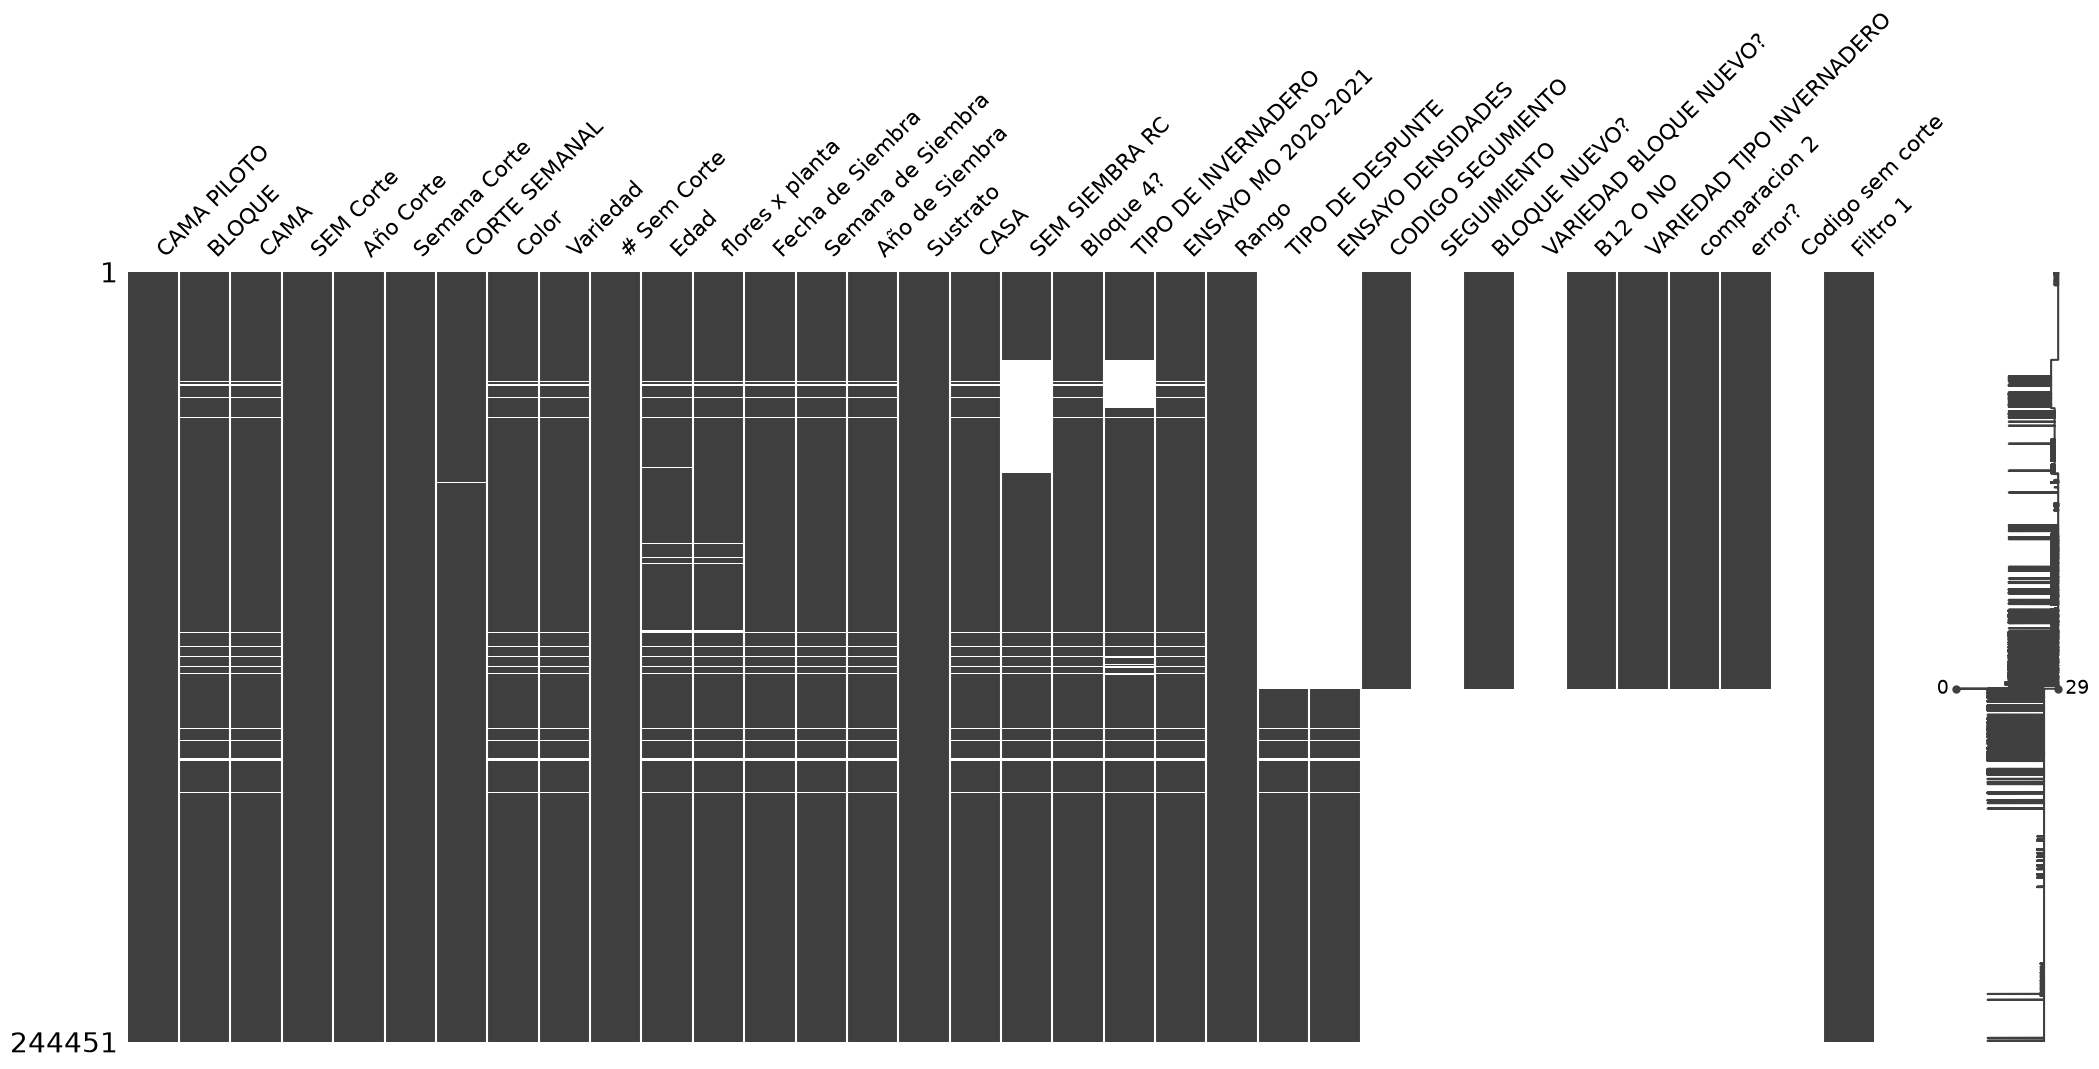

In [48]:
import missingno as msno
import matplotlib.pyplot as plt

# Matriz de valores nulos
msno.matrix(df_curvas)

plt.show()

In [49]:
df_curvas['Filtro 1'].unique()

array([0, 'manejo anterior', nan, 'manejo actual'], dtype=object)

In [52]:
def contar_nan(df, solo_con_nan=True):
    resumen = pd.DataFrame({
        "nan": df.isna().sum(),
        "pct": (df.isna().mean() * 100).round(2),
        "dtype": df.dtypes.astype(str)
    })

    if solo_con_nan:
        resumen = resumen[resumen["nan"] > 0]

    return resumen.sort_values("nan", ascending=False)


# Resumen de valores nulos en df_curvas
resumen_nan_curvas = contar_nan(df_curvas)

resumen_nan_curvas

,nan,pct,dtype
Codigo sem corte,244451,100.00,float64
VARIEDAD BLOQUE NUEVO?,244451,100.00,float64
SEGUIMIENTO,244451,100.00,float64
TIPO DE DESPUNTE,135465,55.42,str
ENSAYO DENSIDADES,135465,55.42,object
error?,112087,45.85,str
comparacion 2,112087,45.85,str
CODIGO SEGUMIENTO,112087,45.85,str
B12 O NO,112087,45.85,str
BLOQUE NUEVO?,112087,45.85,str


A raiz del gráfico de missing tomamos la decisión de eliminar Tipo despunte, Seguimiento, Bloque nuevo, Variedad bloque, B 12 o no. Variedad tipo invernadero, Comparacion 2 erro? Codigo sem corte, Filtro 1

In [54]:
# Eliminación de columnas con muchos valores nulos
columnas_a_eliminar =  [
    "TIPO DE DESPUNTE",
    "ENSAYO DENSIDADES",
    "CODIGO SEGUMIENTO",
    "SEGUIMIENTO",
    "BLOQUE NUEVO?",
    "VARIEDAD BLOQUE NUEVO?",
    "B12 O NO",
    "VARIEDAD TIPO INVERNADERO",
    "comparacion 2",
    "error?",
    "Codigo sem corte",
    "ENSAYO MO 2020-2021",
    "Filtro 1",
    "SEM SIEMBRA RC"

]


df_curvas_clean = df_curvas.drop(columns=columnas_a_eliminar)

df_curvas_clean.head()

,CAMA PILOTO,BLOQUE,CAMA,SEM Corte,Año Corte,Semana Corte,CORTE SEMANAL,Color,Variedad,# Sem Corte,Edad,flores x planta,Fecha de Siembra,Semana de Siembra,Año de Siembra,Sustrato,CASA,Bloque 4?,TIPO DE INVERNADERO,Rango
0,PIGEON-1-6,1.0,6,1.0,2014.0,201401.0,23.0,Cereza,PIGEON,209.0,27.0,0.022908,2013-07-04 00:00:00,27.0,2013.0,S90%,Breier,otros bloques,Tradicional,anterior
1,PIGEON-1-8,1.0,8,1.0,2014.0,201401.0,138.0,Cereza,PIGEON,209.0,27.0,0.137450,2013-07-04 00:00:00,27.0,2013.0,S90%,Breier,otros bloques,Tradicional,anterior
2,BAGATEL-1-13,1.0,13,1.0,2014.0,201401.0,117.0,Blanco,BAGATEL,209.0,86.0,0.200342,2012-05-09 00:00:00,20.0,2012.0,S90%,Selecta,otros bloques,Tradicional,anterior
3,BAGATEL-1-39,1.0,39,1.0,2014.0,201401.0,115.0,Blanco,BAGATEL,209.0,79.0,0.112305,2012-06-29 00:00:00,27.0,2012.0,S90%,Selecta,otros bloques,Tradicional,anterior
4,BAGATEL-1-65,1.0,65,1.0,2014.0,201401.0,155.0,Blanco,BAGATEL,209.0,68.0,0.151961,2012-09-13 00:00:00,38.0,2012.0,S90%,Selecta,otros bloques,Tradicional,anterior


In [55]:
# Resumen de valores nulos en df_curvas
resumen_nan_curvas = contar_nan(df_curvas_clean)

resumen_nan_curvas

,nan,pct,dtype
TIPO DE INVERNADERO,21965,8.99,str
Edad,8157,3.34,float64
flores x planta,7591,3.11,float64
CASA,6321,2.59,object
Color,6181,2.53,str
Año de Siembra,6177,2.53,float64
CAMA,6177,2.53,object
BLOQUE,6177,2.53,float64
Bloque 4?,6177,2.53,str
Fecha de Siembra,6177,2.53,object


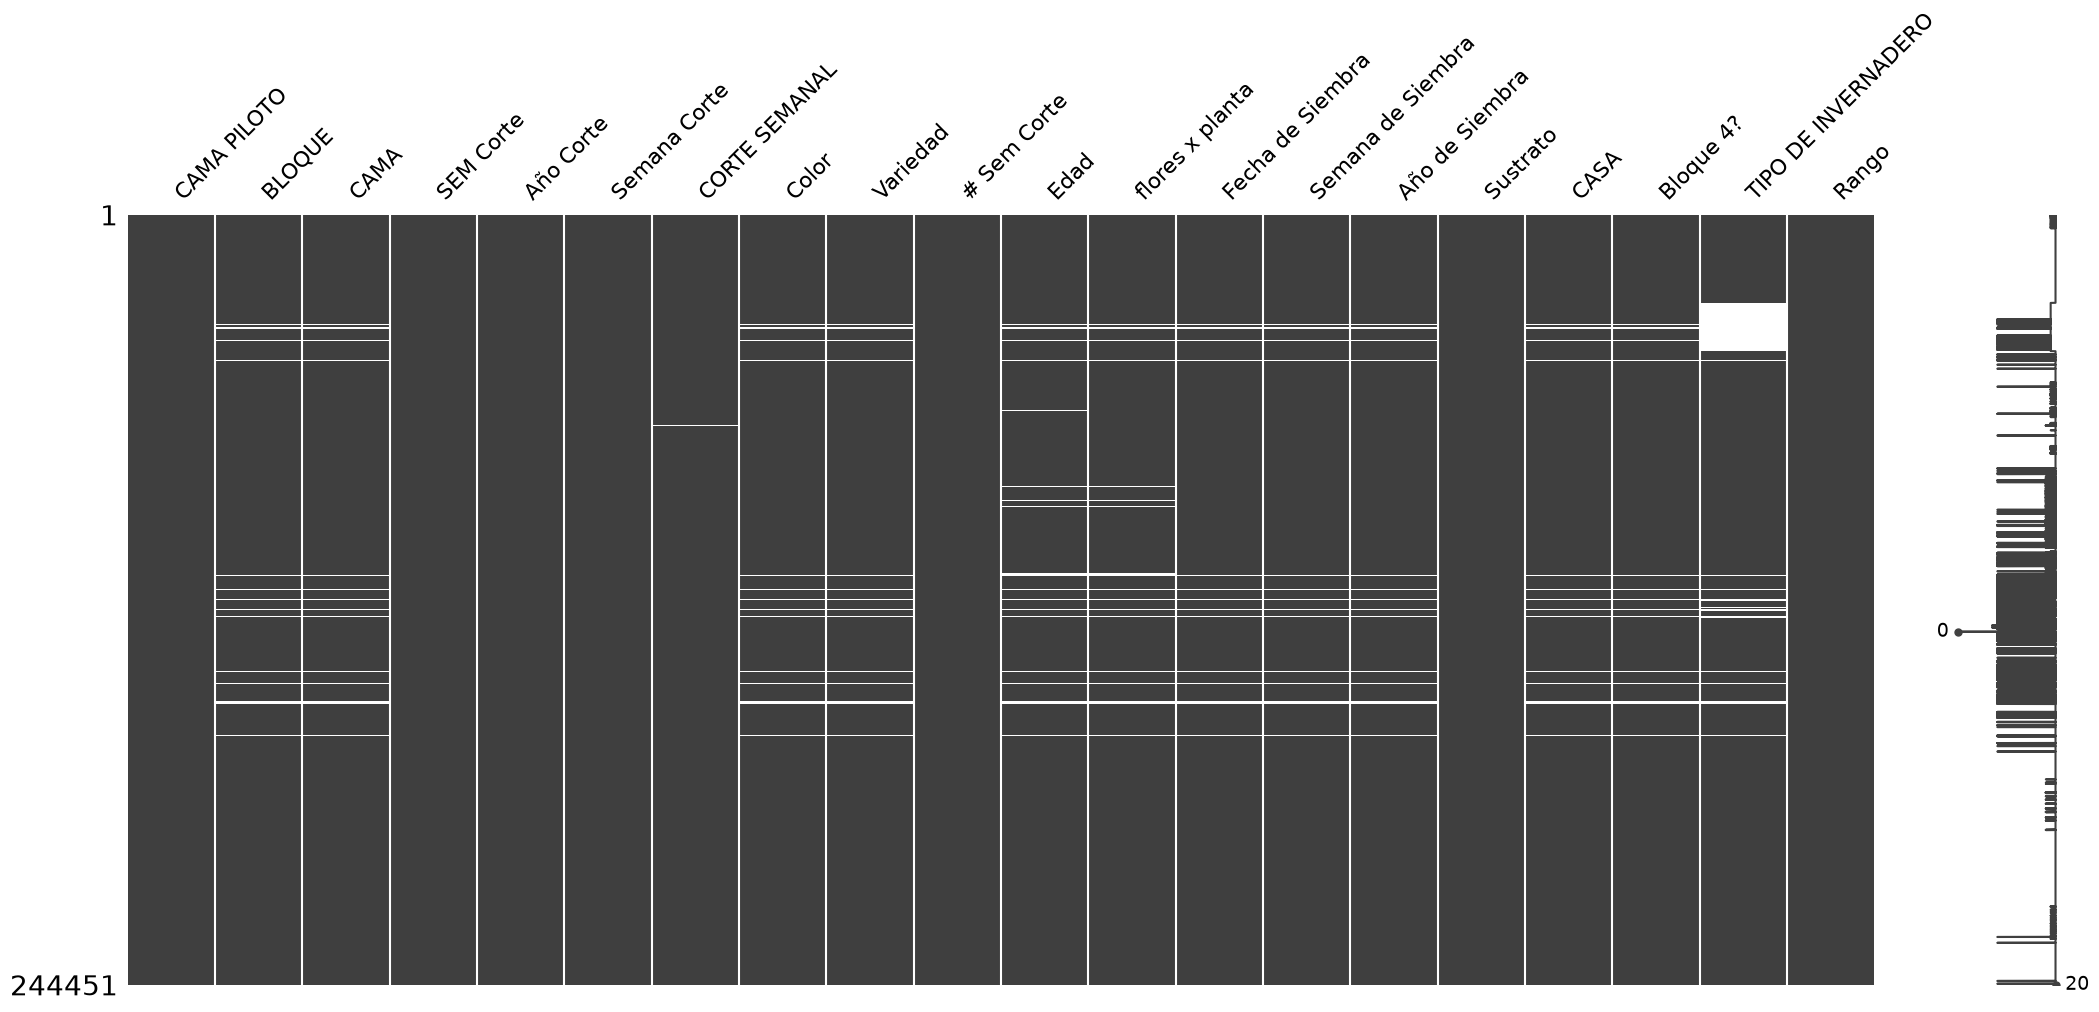

In [58]:
# Matriz de valores nulos
msno.matrix(df_curvas_clean)

plt.show()

In [60]:
#descargar el df "limpio en excel" para compartirlo a anderson
df_curvas_clean.to_excel("df_curvas_clean.xlsx", index=False)


Aqui vamos a quitar las siguientes columnas:

- Seguimiento
- Variedad Bloque Nuevo
- Codigo 